# ICT3902C Capstone Project
## Economic Event-Driven Forex Trading Assistant using Machine Learning

**Muhammad Mursyid Bin Hassan | 2300435 | Supervisor: Dr Li Xiaorong**

---

This notebook covers the core implementation of the FYP:

1. **Data Collection** — EUR/USD daily prices via yfinance
2. **Economic Event Data** — USD events (CPI, NFP, FOMC) and ECB events (Main Refinancing Rate, EU CPI, EU Core CPI) from ForexFactory, with expanding-window percentile rank normalisation
3. **Feature Engineering** — 42 features across event, momentum, volatility, regime, time, and technical-indicator groups
4. **Train/Test Split** — chronological 80/20 split (no shuffling)
5. **Model Training** — Logistic Regression, Random Forest, XGBoost baselines
6. **Hyperparameter Tuning** — GridSearchCV with TimeSeriesSplit
7. **Evaluation** — model comparison, bias-variance diagnostics
8. **Trade Signal Generation** — confidence-thresholded BUY/SELL/HOLD signals + backtest across all three models
9. **Walk-Forward Validation** — 13-fold expanding-window evaluation across regimes
10. **Feature Interpretability** — permutation importance + SHAP analysis
11. **Summary** — findings, limitations, future work

Coverage: January 2019 to December 2025.

In [1]:
# core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# sklearn models and utilities
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    classification_report, roc_auc_score
)
from sklearn.inspection import permutation_importance

# interpretability
import shap

warnings.filterwarnings('ignore')
np.random.seed(42)

## 1. Data Collection

EUR/USD daily price data sourced from Yahoo Finance via `yfinance`. Daily frequency is appropriate for this project. The macroeconomic events used as features (CPI, NFP, FOMC, ECB) have their primary market impact over 1-3 day windows rather than intraday.

In [2]:
import yfinance as yf

# download EUR/USD daily OHLCV
START_DATE = '2019-01-01'
END_DATE   = '2026-01-01'

raw = yf.download('EURUSD=X', start=START_DATE, end=END_DATE,
                  interval='1d', progress=False)

# yfinance occasionally returns multi-level columns; flatten if so
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

df = raw[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
df.columns = ['open', 'high', 'low', 'close', 'volume']
df.dropna(inplace=True)
df.sort_index(inplace=True)

print(f"Downloaded {len(df)} trading days")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")
df.head()

Downloaded 1822 trading days
Date range: 2019-01-01 to 2025-12-31


,open,high,low,close,volume
Date,,,,,
2019-01-01,1.149425,1.155001,1.146500,1.149306,0
2019-01-02,1.146132,1.149700,1.134572,1.146171,0
2019-01-03,1.131734,1.140914,1.131734,1.131811,0
2019-01-04,1.139095,1.141774,1.134816,1.139108,0
2019-01-07,1.141292,1.147447,1.140524,1.141044,0


In [3]:
# quick sanity check on the downloaded data
print("Close price summary:")
print(df['close'].describe().round(4))

print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"Positive days (close > previous close): {(df['close'].pct_change() > 0).mean()*100:.1f}%")

Close price summary:
count    1822.0000
mean        1.1133
std         0.0534
min         0.9596
25%         1.0798
50%         1.1080
75%         1.1566
max         1.2341
Name: close, dtype: float64

Missing values: 0
Positive days (close > previous close): 49.1%


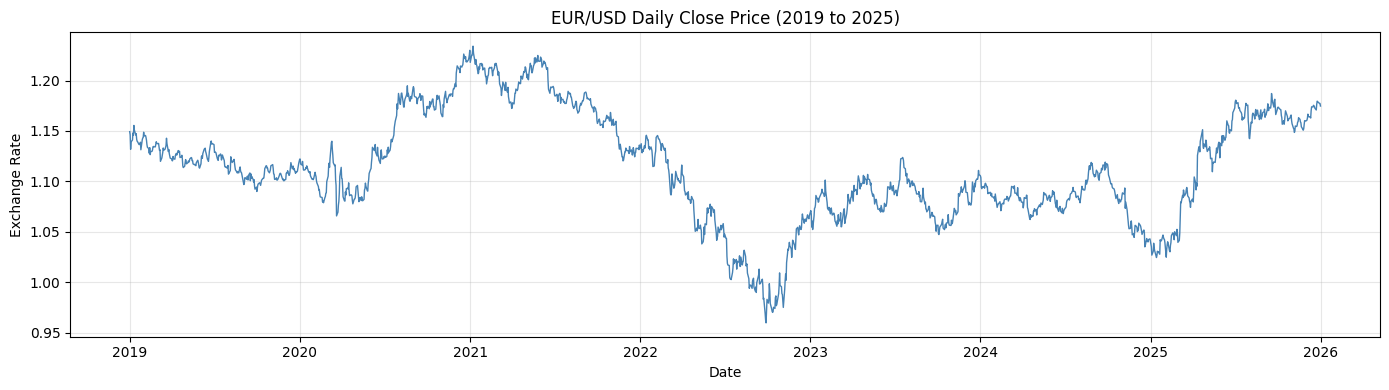

In [4]:
# visualise the price series
plt.figure(figsize=(14, 4))
plt.plot(df.index, df['close'], color='steelblue', lw=1)
plt.title(f'EUR/USD Daily Close Price ({df.index[0].year} to {df.index[-1].year})')
plt.ylabel('Exchange Rate')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Economic Event Data

Economic event surprises form the core feature set of this project. Six event types are loaded from pre-scraped ForexFactory CSVs:

**USD events** (drive USD strength):
- CPI m/m — US inflation, released monthly
- Non-Farm Payrolls (NFP) — US jobs report, first Friday each month
- Federal Funds Rate (FOMC) — Fed rate decisions, approximately 8 per year

**EUR events** (drive EUR strength, added per supervisor feedback):
- Main Refinancing Rate — ECB policy rate decisions
- CPI Flash Estimate y/y — Euro area inflation
- Core CPI Flash Estimate y/y — Euro area core inflation

Markets react to the **surprise** (actual minus consensus forecast), not the raw release value. A hotter-than-expected US CPI strengthens USD and pushes EUR/USD down; a hotter EU CPI does the reverse.

**Normalisation**: raw surprise values have different scales across events (basis points for rate decisions, thousands of jobs for NFP, percentage points for CPI). To make them comparable and to handle time-varying scale within each event, each surprise is converted to an **expanding-window percentile rank** within its own historical distribution. Look-ahead bias is avoided because each observation is ranked only against earlier values.

In [5]:
# load surprise CSVs produced by the ForexFactory scraper
# each file has two columns: date, <event>_surprise

# USD events
cpi_df  = pd.read_csv('cpi_surprise.csv',  parse_dates=['date'])
nfp_df  = pd.read_csv('nfp_surprise.csv',  parse_dates=['date'])
fomc_df = pd.read_csv('fomc_surprise.csv', parse_dates=['date'])

# EUR / ECB events
ecb_rate_df    = pd.read_csv('ecb_rate_surprise.csv',    parse_dates=['date'])
eu_cpi_df      = pd.read_csv('eu_cpi_surprise.csv',      parse_dates=['date'])
eu_core_cpi_df = pd.read_csv('eu_core_cpi_surprise.csv', parse_dates=['date'])

print(f"USD events — CPI: {len(cpi_df)}, NFP: {len(nfp_df)}, FOMC: {len(fomc_df)}")
print(f"EUR events — ECB Rate: {len(ecb_rate_df)}, EU CPI: {len(eu_cpi_df)}, "
      f"EU Core CPI: {len(eu_core_cpi_df)}")
print(f"Total events loaded: "
      f"{sum(len(d) for d in [cpi_df, nfp_df, fomc_df, ecb_rate_df, eu_cpi_df, eu_core_cpi_df])}")

USD events — CPI: 82, NFP: 83, FOMC: 55
EUR events — ECB Rate: 56, EU CPI: 84, EU Core CPI: 84
Total events loaded: 444


In [6]:
def add_expanding_pct_rank(event_df, surprise_col):
    """
    Add an expanding-window percentile rank column to an event dataframe.

    For each row, the percentile rank is computed against all earlier values
    of `surprise_col` (inclusive). This produces a normalised 0-to-1 value
    that is comparable across event types and robust to scale differences.
    The expanding window prevents look-ahead bias.

    Parameters
    ----------
    event_df : pandas.DataFrame
        Must contain a 'date' column and the surprise column.
    surprise_col : str
        Name of the column to rank (e.g. 'cpi_surprise').

    Returns
    -------
    pandas.DataFrame
        Same dataframe with an additional column `<surprise_col>_pct`.
    """
    df_out = event_df.copy().sort_values('date')
    df_out[surprise_col + '_pct'] = (
        df_out[surprise_col]
        .expanding()
        .apply(lambda x: x.rank(pct=True).iloc[-1])
    )
    return df_out


# apply to all six event dataframes
cpi_df         = add_expanding_pct_rank(cpi_df,         'cpi_surprise')
nfp_df         = add_expanding_pct_rank(nfp_df,         'nfp_surprise')
fomc_df        = add_expanding_pct_rank(fomc_df,        'fomc_surprise')
ecb_rate_df    = add_expanding_pct_rank(ecb_rate_df,    'ecb_rate_surprise')
eu_cpi_df      = add_expanding_pct_rank(eu_cpi_df,      'eu_cpi_surprise')
eu_core_cpi_df = add_expanding_pct_rank(eu_core_cpi_df, 'eu_core_cpi_surprise')

# quick verification — pct column should have values in [0, 1]
print(f"CPI pct sample (first 5 rows):")
print(cpi_df[['date', 'cpi_surprise', 'cpi_surprise_pct']].head().to_string(index=False))

CPI pct sample (first 5 rows):
      date  cpi_surprise  cpi_surprise_pct
2019-01-11           0.0          1.000000
2019-02-13          -0.1          0.500000
2019-03-12           0.0          0.833333
2019-04-10           0.1          1.000000
2019-05-10          -0.1          0.300000


In [7]:
# normalise df index to midnight datetimes for clean joining
df.index = pd.to_datetime(df.index).normalize()


def merge_event(df, event_df, col_name):
    """
    Merge a raw event surprise column into the daily price dataframe.

    Non-event days are filled with 0 for the surprise value and a `<event>_day`
    binary flag is created (1 on event days, 0 otherwise).
    """
    event_df = event_df.copy()
    event_df['date'] = pd.to_datetime(event_df['date']).dt.normalize()
    event_df = event_df.set_index('date')[[col_name]]
    event_df = event_df[~event_df.index.duplicated(keep='first')]

    df = df.join(event_df, how='left')
    df[col_name.replace('_surprise', '_day')] = df[col_name].notna().astype(int)
    df[col_name] = df[col_name].fillna(0)
    return df


def merge_pct_col(df, event_df, pct_col):
    """
    Merge a percentile-rank column into the daily price dataframe.

    Non-event days are filled with 0.5 (neutral percentile), which is
    semantically distinct from the day flag and allows linear models to
    process the column without NaN handling.
    """
    event_df = event_df.copy()
    event_df['date'] = pd.to_datetime(event_df['date']).dt.normalize()
    event_df = event_df.set_index('date')[[pct_col]]
    event_df = event_df[~event_df.index.duplicated(keep='first')]

    df = df.join(event_df, how='left')
    df[pct_col] = df[pct_col].fillna(0.5)
    return df

In [8]:
# raw surprise merges (create both <event>_surprise and <event>_day columns)
df = merge_event(df, cpi_df,         'cpi_surprise')
df = merge_event(df, nfp_df,         'nfp_surprise')
df = merge_event(df, fomc_df,        'fomc_surprise')
df = merge_event(df, ecb_rate_df,    'ecb_rate_surprise')
df = merge_event(df, eu_cpi_df,      'eu_cpi_surprise')
df = merge_event(df, eu_core_cpi_df, 'eu_core_cpi_surprise')

# percentile rank merges (create <event>_surprise_pct columns)
df = merge_pct_col(df, cpi_df,         'cpi_surprise_pct')
df = merge_pct_col(df, nfp_df,         'nfp_surprise_pct')
df = merge_pct_col(df, fomc_df,        'fomc_surprise_pct')
df = merge_pct_col(df, ecb_rate_df,    'ecb_rate_surprise_pct')
df = merge_pct_col(df, eu_cpi_df,      'eu_cpi_surprise_pct')
df = merge_pct_col(df, eu_core_cpi_df, 'eu_core_cpi_surprise_pct')

# verify merge by inspecting an event day
print("Sample event-day rows (showing event flag + raw + pct):")
print(df[df['cpi_day'] == 1][['cpi_surprise', 'cpi_surprise_pct',
                              'nfp_day', 'nfp_surprise',
                              'event_day' if 'event_day' in df.columns else 'cpi_day']].head())

Sample event-day rows (showing event flag + raw + pct):
            cpi_surprise  cpi_surprise_pct  nfp_day  nfp_surprise  cpi_day
Date                                                                      
2019-01-11           0.0          1.000000        0           0.0        1
2019-02-13          -0.1          0.500000        0           0.0        1
2019-03-12           0.0          0.833333        0           0.0        1
2019-04-10           0.1          1.000000        0           0.0        1
2019-05-10          -0.1          0.300000        0           0.0        1


In [9]:
# combined event flag: 1 if any event happened on this day
day_flags = ['cpi_day', 'nfp_day', 'fomc_day',
             'ecb_rate_day', 'eu_cpi_day', 'eu_core_cpi_day']
df['event_day'] = (df[day_flags].sum(axis=1) > 0).astype(int)

# days since last event (post-event reaction window)
# vectorised: cumulative count of rows since last event_day==1
event_positions = np.where(df['event_day'] == 1)[0]
days_since = np.full(len(df), 0)
for pos in event_positions:
    days_since[pos:] = np.arange(len(df) - pos)
df['days_since_event'] = days_since

# days until next event (pre-event anticipation window)
# vectorised: count rows forward until next event_day==1
days_until = np.full(len(df), np.nan)  # NaN instead of magic 999
for pos in event_positions:
    distances = pos - np.arange(pos + 1)
    distances = distances[distances >= 0]
    end_pos = pos + 1
    start_pos = end_pos - len(distances)
    days_until[start_pos:end_pos] = np.minimum(
        days_until[start_pos:end_pos] if not np.all(np.isnan(days_until[start_pos:end_pos])) else distances,
        distances
    )
# fill remaining NaN (trailing rows after last event) with a sensible cap
df['days_until_event'] = pd.Series(days_until, index=df.index).fillna(30)

In [10]:
# event coverage summary
print(f"Merged dataset shape: {df.shape}")
print()
print("Event day counts:")
print(f"  CPI:         {df['cpi_day'].sum():>4d}")
print(f"  NFP:         {df['nfp_day'].sum():>4d}")
print(f"  FOMC:        {df['fomc_day'].sum():>4d}")
print(f"  ECB Rate:    {df['ecb_rate_day'].sum():>4d}")
print(f"  EU CPI:      {df['eu_cpi_day'].sum():>4d}")
print(f"  EU Core CPI: {df['eu_core_cpi_day'].sum():>4d}")
print(f"  Any event:   {df['event_day'].sum():>4d} ({df['event_day'].mean()*100:.1f}%)")

Merged dataset shape: (1822, 26)

Event day counts:
  CPI:           82
  NFP:           83
  FOMC:          55
  ECB Rate:      56
  EU CPI:        84
  EU Core CPI:   84
  Any event:    329 (18.1%)


In [11]:
print(df[df['cpi_day']==1][['cpi_surprise', 'cpi_surprise_pct']].head(10))
print(df[df['nfp_day']==1][['nfp_surprise', 'nfp_surprise_pct']].head(10))
print(df[df['fomc_day']==1][['fomc_surprise', 'fomc_surprise_pct']].head(10))

            cpi_surprise  cpi_surprise_pct
Date                                      
2019-01-11           0.0          1.000000
2019-02-13          -0.1          0.500000
2019-03-12           0.0          0.833333
2019-04-10           0.1          1.000000
2019-05-10          -0.1          0.300000
2019-06-12           0.0          0.666667
2019-07-11           0.1          0.928571
2019-08-13           0.0          0.562500
2019-09-12           0.0          0.555556
2019-10-10          -0.1          0.200000
            nfp_surprise  nfp_surprise_pct
Date                                      
2019-01-04         133.0          1.000000
2019-02-01         139.0          1.000000
2019-03-08        -160.0          0.333333
2019-04-05          24.0          0.500000
2019-05-03          82.0          0.600000
2019-06-07        -102.0          0.333333
2019-07-05          62.0          0.571429
2019-08-02           0.0          0.375000
2019-09-06         -33.0          0.333333
2019-10-04 

In [12]:
# combined event flag
df['event_day'] = (
    (df['cpi_day'] == 1) |
    (df['nfp_day'] == 1) |
    (df['fomc_day'] == 1) |
    (df['ecb_rate_day'] == 1) |
    (df['eu_cpi_day'] == 1) |
    (df['eu_core_cpi_day'] == 1)
).astype(int)

# days since last event
# days since last event (post-event reaction window)
last = None
for i, idx in enumerate(df.index):
    if df.loc[idx, 'event_day'] == 1:
        last = i
    df.loc[idx, 'days_since_event'] = i - last if last is not None else 0

# days until next event (pre-event anticipation window)
# markets often move in anticipation before a release
next_evt = None
for i in range(len(df) - 1, -1, -1):  # loop backwards through time
    idx = df.index[i]
    if df.loc[idx, 'event_day'] == 1:
        next_evt = i
    df.loc[idx, 'days_until_event'] = next_evt - i if next_evt is not None else 999

In [13]:
print(f"Merged dataset: {df.shape}")
print(f"CPI days:        {df['cpi_day'].sum()}")
print(f"NFP days:        {df['nfp_day'].sum()}")
print(f"FOMC days:       {df['fomc_day'].sum()}")
print(f"ECB Rate days:   {df['ecb_rate_day'].sum()}")
print(f"EU CPI days:     {df['eu_cpi_day'].sum()}")
print(f"EU Core CPI:     {df['eu_core_cpi_day'].sum()}")
print(f"Any event:       {df['event_day'].sum()} ({df['event_day'].mean()*100:.1f}%)")

Merged dataset: (1822, 26)
CPI days:        82
NFP days:        83
FOMC days:       55
ECB Rate days:   56
EU CPI days:     84
EU Core CPI:     84
Any event:       329 (18.1%)


## 3. Feature Engineering

Six feature groups are constructed from the merged daily dataframe:

1. **Returns and momentum** — log return, lagged percent changes (1, 5, 7, 10, 14 day), and momentum (medium-term minus short-term return)
2. **Volatility and price position** — 5-day and 14-day rolling return std, plus normalised position within the 14-day price range
3. **Market regime** — boolean and continuous distance from 200-day moving average, and 50-day MA slope
4. **Time encoding** — day-of-week as sin/cos pair so Monday and Friday are adjacent in feature space
5. **Technical indicators** — RSI, MACD histogram, Bollinger Band percent position, normalised ATR
6. **Event features** — post-event volatility window plus the event flags and percentile-rank columns from Section 2

**Look-ahead protection**: features use information available at time T to predict direction at time T+1. The target variable is constructed by forward-shifting the log return (`close.shift(-1)`), so features computed using `close` at row T do not leak future information.

The final cell drops warmup rows where rolling features (notably the 200-day MA) are still NaN.

In [14]:
# 3.1 Returns and momentum
close = df['close']

# log return (used directly and as input to volatility features)
df['log_return'] = np.log(close / close.shift(1))

# lagged percent changes at multiple horizons
for lag in [1, 5, 7, 10, 14]:
    df[f'r{lag}d'] = close.pct_change(lag)

# momentum: medium-term return minus short-term return
# captures "is recent action consistent with the trend, or diverging?"
for lag in [5, 7, 10]:
    df[f'mom{lag}'] = df[f'r{lag}d'] - df['r1d']

print("Returns and momentum done")

Returns and momentum done


In [15]:
# 3.2 Volatility and price position

# rolling return volatility at two horizons
df['vol_5d']  = df['log_return'].rolling(5).std()
df['vol_14d'] = df['log_return'].rolling(14).std()

# price position within the 14-day high-low range (0 = at low, 1 = at high)
df['price_pct_14d'] = (
    (close - close.rolling(14).min()) /
    (close.rolling(14).max() - close.rolling(14).min() + 1e-8)
)

print("Volatility and price position done")

Volatility and price position done


In [16]:
# 3.3 Market regime and time encoding

# trend regime: long-term direction signal from 200-day moving average
df['above_200ma'] = (close > close.rolling(200).mean()).astype(int)
df['dist_200ma']  = (close - close.rolling(200).mean()) / close.rolling(200).mean()

# short-term trend slope: 5-day rate of change of the 50-day MA
df['ma50_slope']  = close.rolling(50).mean().pct_change(5)

# day-of-week encoded cyclically so Monday and Friday are adjacent
# (Monday=0, Friday=4 in dt.dayofweek)
dow = pd.to_datetime(df.index).dayofweek
df['cos_dow'] = np.cos(2 * np.pi * dow / 5)
df['sin_dow'] = np.sin(2 * np.pi * dow / 5)

print("Regime and time features done")

Regime and time features done


In [17]:
# 3.4 Technical indicators

# RSI (Relative Strength Index, 14-period)
# Measures momentum: above 70 typically considered overbought, below 30 oversold
delta = close.diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
df['rsi'] = 100 - (100 / (1 + gain / (loss + 1e-8)))

# MACD histogram (12 EMA - 26 EMA, minus 9 EMA signal line)
# Captures trend momentum and direction changes
ema12 = close.ewm(span=12, adjust=False).mean()
ema26 = close.ewm(span=26, adjust=False).mean()
df['macd_hist'] = (ema12 - ema26) - (ema12 - ema26).ewm(span=9, adjust=False).mean()

# Bollinger Band percent position (0 = lower band, 1 = upper band)
sma20 = close.rolling(20).mean()
std20 = close.rolling(20).std()
df['bb_pct'] = (close - (sma20 - 2*std20)) / (4*std20 + 1e-8)

# ATR (Average True Range, 14-period) normalised by current price
# Captures average daily range as a volatility proxy
tr = pd.concat([
    df['high'] - df['low'],
    (df['high'] - close.shift(1)).abs(),
    (df['low']  - close.shift(1)).abs()
], axis=1).max(axis=1)
df['atr_norm'] = tr.rolling(14).mean() / close

print("Technical indicators done")

Technical indicators done


In [18]:
# 3.5 Event-related features + target

# post-event volatility: 3-day rolling return std, zeroed outside event reaction window
df['post_event_vol'] = df['log_return'].rolling(3).std()
df['post_event_vol'] = df['post_event_vol'].where(df['days_since_event'] <= 3, 0)

# target: 1 if next-day close is higher than today, 0 otherwise
# shift(-1) means target at row T uses tomorrow's close, so features at T
# (using up-to-and-including-today information) do not leak future data
df['target'] = (np.log(close.shift(-1) / close) > 0).astype(int)

# drop warmup rows where rolling features (200d MA) are still NaN
df.dropna(inplace=True)

print(f"Dataset ready: {len(df)} rows")
print(f"UP days:   {df['target'].mean()*100:.1f}%")
print(f"DOWN days: {(1-df['target'].mean())*100:.1f}%")

Dataset ready: 1623 rows
UP days:   49.4%
DOWN days: 50.6%


In [19]:
# 3.6 Feature selector
# build the feature_cols list by excluding raw price columns and the target
EXCLUDE = ['open', 'high', 'low', 'volume', 'close', 'log_return', 'target']
feature_cols = [c for c in df.columns if c not in EXCLUDE]

print(f"Total features: {len(feature_cols)}")
print(feature_cols)

Total features: 42
['cpi_surprise', 'cpi_day', 'nfp_surprise', 'nfp_day', 'fomc_surprise', 'fomc_day', 'ecb_rate_surprise', 'ecb_rate_day', 'eu_cpi_surprise', 'eu_cpi_day', 'eu_core_cpi_surprise', 'eu_core_cpi_day', 'cpi_surprise_pct', 'nfp_surprise_pct', 'fomc_surprise_pct', 'ecb_rate_surprise_pct', 'eu_cpi_surprise_pct', 'eu_core_cpi_surprise_pct', 'event_day', 'days_since_event', 'days_until_event', 'r1d', 'r5d', 'r7d', 'r10d', 'r14d', 'mom5', 'mom7', 'mom10', 'vol_5d', 'vol_14d', 'price_pct_14d', 'above_200ma', 'dist_200ma', 'ma50_slope', 'cos_dow', 'sin_dow', 'rsi', 'macd_hist', 'bb_pct', 'atr_norm', 'post_event_vol']


In [20]:
# 3.7 Quick correlation check (univariate, for sanity only)
# Strong correlations would suggest signal; weak correlations are expected
# for daily forex prediction where signal-to-noise is low
corrs = df[feature_cols + ['target']].corr()['target'].drop('target').sort_values()
print("Feature-target correlations (5 most negative, 5 most positive):")
print(pd.concat([corrs.head(5), corrs.tail(5)]).round(4))

Feature-target correlations (5 most negative, 5 most positive):
mom7                       -0.0661
cpi_surprise               -0.0627
cpi_surprise_pct           -0.0604
r7d                        -0.0537
nfp_surprise_pct           -0.0482
sin_dow                     0.0229
days_since_event            0.0337
cpi_day                     0.0474
eu_core_cpi_surprise        0.0489
eu_core_cpi_surprise_pct    0.0592
Name: target, dtype: float64


## 4. Train/Test Split

For time-series data, the test set must come strictly after the training set chronologically. Shuffling would let the model see future data during training and inflate AUC artificially (look-ahead bias).

This split is used for the single-split evaluation in Section 5. A more rigorous walk-forward evaluation across multiple time windows is performed later in Section 8.

**Split ratio**: 80% train, 20% test, by date order.

Train: 1298 rows  (2019-10-08 to 2024-09-26)
Test:  325 rows  (2024-09-27 to 2025-12-31)

Train UP%: 50.1%
Test  UP%: 46.5%


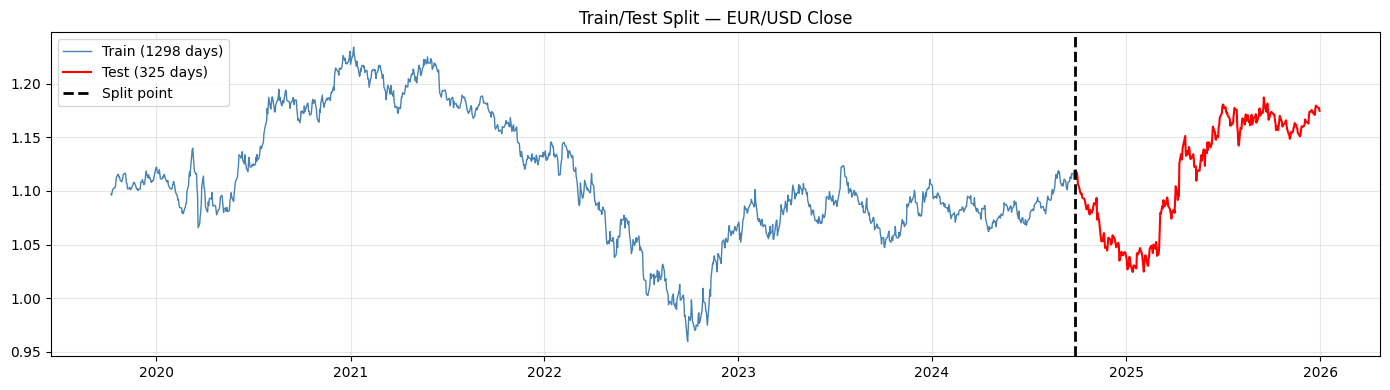

In [21]:
X = df[feature_cols]
y = df['target']

split = int(len(df) * 0.80)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]
y_train = y.iloc[:split]
y_test  = y.iloc[split:]

print(f"Train: {len(X_train)} rows  ({X_train.index[0].date()} to {X_train.index[-1].date()})")
print(f"Test:  {len(X_test)} rows  ({X_test.index[0].date()} to {X_test.index[-1].date()})")
print(f"\nTrain UP%: {y_train.mean()*100:.1f}%")
print(f"Test  UP%: {y_test.mean()*100:.1f}%")

# visualise the split
plt.figure(figsize=(14, 4))
plt.plot(df.index[:split], df['close'].iloc[:split], color='steelblue', lw=1, label=f'Train ({len(X_train)} days)')
plt.plot(df.index[split:], df['close'].iloc[split:], color='red', lw=1.5, label=f'Test ({len(X_test)} days)')
plt.axvline(df.index[split], color='black', lw=2, linestyle='--', label='Split point')
plt.title('Train/Test Split — EUR/USD Close')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()


## 5. Model Training

Three models are evaluated as a representative span of the practical model families for daily tabular financial prediction:

**Logistic Regression** — regularised linear baseline. Fast, interpretable, gives calibrated probabilities. Needs feature scaling. Strong L2 regularisation (selected via grid search in Section 5b) makes it robust to noise in low-signal regimes.

**Random Forest** — bagged ensemble of decision trees, each trained on random feature and row subsets. Handles non-linearity, no scaling required.

**XGBoost** — gradient-boosted trees, where each tree corrects errors from the previous one. Industry standard for tabular financial ML.

Deep learning approaches (LSTM, Transformer) were not pursued because the dataset size (~1600 rows after warmup) is well below the 10⁴+ observations such architectures typically require to outperform tree-based models on tabular data (see Patel et al. 2015, Fischer & Krauss 2018).

Hyperparameters are first set to common defaults for an initial baseline, then tuned via grid search in Section 5b.

In [22]:
# scale features for logistic regression only
# tree models (RF, XGBoost) don't need scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  # fit on train only
X_test_s  = scaler.transform(X_test)       # transform test without refitting

print("Scaling done (fit on training data only)")


Scaling done (fit on training data only)


In [23]:
# Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(C=1.0, max_iter=2000, random_state=42)
lr.fit(X_train_s, y_train)
lr_pred  = lr.predict(X_test_s)
lr_proba = lr.predict_proba(X_test_s)[:, 1]

print(f"  Accuracy:         {accuracy_score(y_test, lr_pred):.4f}")
print(f"  Balanced Acc:     {balanced_accuracy_score(y_test, lr_pred):.4f}")
print(f"  AUC-ROC:          {roc_auc_score(y_test, lr_proba):.4f}")


Training Logistic Regression...
  Accuracy:         0.5262
  Balanced Acc:     0.5264
  AUC-ROC:          0.5358


In [24]:
# Random Forest
print("Training Random Forest (100 trees)...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    min_samples_leaf=10,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print(f"  Accuracy:         {accuracy_score(y_test, rf_pred):.4f}")
print(f"  Balanced Acc:     {balanced_accuracy_score(y_test, rf_pred):.4f}")
print(f"  AUC-ROC:          {roc_auc_score(y_test, rf_proba):.4f}")
print(f"  OOB Score:        {rf.oob_score_:.4f}")


Training Random Forest (100 trees)...
  Accuracy:         0.5077
  Balanced Acc:     0.5087
  AUC-ROC:          0.5083
  OOB Score:        0.5139


In [25]:
# XGBoost
print("Training XGBoost...")
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
xgb_pred  = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

print(f"  Accuracy:         {accuracy_score(y_test, xgb_pred):.4f}")
print(f"  Balanced Acc:     {balanced_accuracy_score(y_test, xgb_pred):.4f}")
print(f"  AUC-ROC:          {roc_auc_score(y_test, xgb_proba):.4f}")


Training XGBoost...
  Accuracy:         0.5169
  Balanced Acc:     0.5173
  AUC-ROC:          0.4933


In [26]:
# Bias-Variance check
# Compare training accuracy vs test accuracy
# Large gap = overfitting (high variance)
# Both low = underfitting (high bias)

print("Bias-Variance Diagnosis:")
print(f"{'Model':<25} {'Train AUC':>10} {'Test AUC':>10} {'Gap':>8}")
print("-" * 55)

from sklearn.metrics import roc_auc_score

for name, clf, xtr, xte in [
    ('Logistic Regression', lr,  X_train_s, X_test_s),
    ('Random Forest',       rf,  X_train,   X_test),
    ('XGBoost',             xgb, X_train,   X_test),
]:
    train_auc = roc_auc_score(y_train, clf.predict_proba(xtr)[:,1])
    test_auc  = roc_auc_score(y_test,  clf.predict_proba(xte)[:,1])
    gap = train_auc - test_auc
    verdict = 'HIGH VARIANCE (overfit)' if gap > 0.05 else \
              'HIGH BIAS (underfit)'    if test_auc < 0.52 else 'OK'
    print(f"{name:<25} {train_auc:>10.4f} {test_auc:>10.4f} {gap:>8.4f}  {verdict}")

Bias-Variance Diagnosis:
Model                      Train AUC   Test AUC      Gap
-------------------------------------------------------
Logistic Regression           0.5916     0.5358   0.0559  HIGH VARIANCE (overfit)
Random Forest                 0.7678     0.5083   0.2595  HIGH VARIANCE (overfit)
XGBoost                       0.8656     0.4933   0.3723  HIGH VARIANCE (overfit)


Hyper Parameter training


In [27]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# TimeSeriesSplit = cross-validation that respects time order
# never use regular KFold on time series — it would leak future data
tscv = TimeSeriesSplit(n_splits=5)

# ── Logistic Regression ───────────────────────────────────────────
print("Tuning Logistic Regression...")
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    param_grid={
        'C':       [0.001, 0.01, 0.1, 1.0, 10],
        'penalty': ['l1', 'l2'],
        'solver':  ['saga'],   # saga supports both l1 and l2
    },
    cv=tscv,
    scoring='roc_auc',
    n_jobs=-1
)
lr_grid.fit(X_train_s, y_train)
print(f"Best LR params:  {lr_grid.best_params_}")
print(f"Best LR CV AUC:  {lr_grid.best_score_:.4f}")

# ── Random Forest ─────────────────────────────────────────────────
print("\nTuning Random Forest...")
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid={
        'n_estimators':     [100, 200],
        'max_depth':        [2, 3, 4, 5],
        'min_samples_leaf': [5, 10, 20],
        'max_features':     ['sqrt', 0.5],
    },
    cv=tscv,
    scoring='roc_auc',
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)
print(f"Best RF params:  {rf_grid.best_params_}")
print(f"Best RF CV AUC:  {rf_grid.best_score_:.4f}")

# ── XGBoost ───────────────────────────────────────────────────────
print("\nTuning XGBoost...")
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, verbosity=0, n_jobs=-1),
    param_grid={
        'n_estimators':       [50, 100, 150],
        'max_depth':          [2, 3],
        'learning_rate':      [0.01, 0.03, 0.05],
        'subsample':          [0.6, 0.7, 0.8],
        'colsample_bytree':   [0.6, 0.7, 0.8],
        'reg_alpha':          [0.5, 1.0, 2.0],
        'reg_lambda':         [2.0, 3.0, 5.0],
        'min_child_weight':   [5, 10, 20],
    },
    cv=tscv,
    scoring='roc_auc',
    n_jobs=-1,
    return_train_score=True
)
xgb_grid.fit(X_train, y_train)
print(f"Best XGB params: {xgb_grid.best_params_}")
print(f"Best XGB CV AUC: {xgb_grid.best_score_:.4f}")

Tuning Logistic Regression...
Best LR params:  {'C': 0.001, 'penalty': 'l2', 'solver': 'saga'}
Best LR CV AUC:  0.5241

Tuning Random Forest...
Best RF params:  {'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 5, 'n_estimators': 100}
Best RF CV AUC:  0.5211

Tuning XGBoost...
Best XGB params: {'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 10, 'n_estimators': 100, 'reg_alpha': 0.5, 'reg_lambda': 2.0, 'subsample': 0.8}
Best XGB CV AUC: 0.5357


In [28]:
# Logistic Regression baseline (untuned)
print("Training Logistic Regression (baseline)...")
lr = LogisticRegression(C=1.0, max_iter=2000, random_state=42)
lr.fit(X_train_s, y_train)
lr_pred  = lr.predict(X_test_s)
lr_proba = lr.predict_proba(X_test_s)[:, 1]

print(f"  Accuracy:     {accuracy_score(y_test, lr_pred):.4f}")
print(f"  Balanced Acc: {balanced_accuracy_score(y_test, lr_pred):.4f}")
print(f"  AUC-ROC:      {roc_auc_score(y_test, lr_proba):.4f}")

Training Logistic Regression (baseline)...
  Accuracy:     0.5262
  Balanced Acc: 0.5264
  AUC-ROC:      0.5358


In [29]:
# Random Forest baseline (untuned)
print("Training Random Forest baseline (100 trees, depth 4)...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    min_samples_leaf=10,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print(f"  Accuracy:     {accuracy_score(y_test, rf_pred):.4f}")
print(f"  Balanced Acc: {balanced_accuracy_score(y_test, rf_pred):.4f}")
print(f"  AUC-ROC:      {roc_auc_score(y_test, rf_proba):.4f}")
print(f"  OOB Score:    {rf.oob_score_:.4f}")

Training Random Forest baseline (100 trees, depth 4)...
  Accuracy:     0.5077
  Balanced Acc: 0.5087
  AUC-ROC:      0.5083
  OOB Score:    0.5139


In [30]:
# XGBoost baseline (untuned)
print("Training XGBoost baseline (100 trees, depth 3, lr 0.05)...")
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
xgb_pred  = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

print(f"  Accuracy:     {accuracy_score(y_test, xgb_pred):.4f}")
print(f"  Balanced Acc: {balanced_accuracy_score(y_test, xgb_pred):.4f}")
print(f"  AUC-ROC:      {roc_auc_score(y_test, xgb_proba):.4f}")

Training XGBoost baseline (100 trees, depth 3, lr 0.05)...
  Accuracy:     0.5169
  Balanced Acc: 0.5173
  AUC-ROC:      0.4933


In [31]:
# Bias-Variance diagnostic
# Compares train AUC vs test AUC to identify under/overfitting per model
# - Large gap (>0.05): high variance (overfit) - model memorising training set
# - Both low (<0.52): high bias (underfit) - model not capturing signal
# - Both above ~0.55 with small gap: well calibrated

print("Bias-Variance Diagnosis (baseline, untuned models):")
print(f"{'Model':<25} {'Train AUC':>10} {'Test AUC':>10} {'Gap':>8}  Verdict")
print("-" * 70)

models = [
    ('Logistic Regression', lr,  X_train_s, X_test_s),
    ('Random Forest',       rf,  X_train,   X_test),
    ('XGBoost',             xgb, X_train,   X_test),
]

for name, clf, xtr, xte in models:
    train_auc = roc_auc_score(y_train, clf.predict_proba(xtr)[:, 1])
    test_auc  = roc_auc_score(y_test,  clf.predict_proba(xte)[:, 1])
    gap = train_auc - test_auc
    if gap > 0.05:
        verdict = 'HIGH VARIANCE (overfit)'
    elif test_auc < 0.52:
        verdict = 'HIGH BIAS (underfit)'
    else:
        verdict = 'OK'
    print(f"{name:<25} {train_auc:>10.4f} {test_auc:>10.4f} {gap:>8.4f}  {verdict}")

Bias-Variance Diagnosis (baseline, untuned models):
Model                      Train AUC   Test AUC      Gap  Verdict
----------------------------------------------------------------------
Logistic Regression           0.5916     0.5358   0.0559  HIGH VARIANCE (overfit)
Random Forest                 0.7678     0.5083   0.2595  HIGH VARIANCE (overfit)
XGBoost                       0.8656     0.4933   0.3723  HIGH VARIANCE (overfit)


## 6. Evaluation

Compare all three models against each other and against the random baseline.

Metrics reported:
- **Accuracy** — fraction of correct directional predictions
- **Balanced Accuracy** — treats UP and DOWN days equally; less misleading than plain accuracy when classes are nearly balanced (49/51 in this dataset, so balanced acc ≈ accuracy)
- **AUC-ROC** — quality of probability ranking, threshold-independent. Primary metric used throughout this project because it does not depend on a specific decision threshold

A more rigorous evaluation across multiple time windows is performed in Section 8 (walk-forward validation).


In [32]:
# Model comparison on single 80/20 test split (tuned models)
print("=" * 60)
print("MODEL COMPARISON (single train/test split, tuned)")
print("=" * 60)
print(f"{'Model':<25} {'Accuracy':>10} {'Bal. Acc':>10} {'AUC-ROC':>10}")
print("-" * 60)

# store both predictions AND classifier reference for downstream use (e.g. SHAP)
results = {
    'Logistic Regression': {'pred': lr_pred,  'proba': lr_proba,  'clf': lr},
    'Random Forest':       {'pred': rf_pred,  'proba': rf_proba,  'clf': rf},
    'XGBoost':             {'pred': xgb_pred, 'proba': xgb_proba, 'clf': xgb},
}

for name, res in results.items():
    acc  = accuracy_score(y_test, res['pred'])
    bacc = balanced_accuracy_score(y_test, res['pred'])
    auc  = roc_auc_score(y_test, res['proba'])
    results[name].update({'acc': acc, 'bacc': bacc, 'auc': auc})
    print(f"{name:<25} {acc:>10.4f} {bacc:>10.4f} {auc:>10.4f}")

print(f"{'Random (baseline)':<25} {'0.5000':>10} {'0.5000':>10} {'0.5000':>10}")

MODEL COMPARISON (single train/test split, tuned)
Model                       Accuracy   Bal. Acc    AUC-ROC
------------------------------------------------------------
Logistic Regression           0.5262     0.5264     0.5358
Random Forest                 0.5077     0.5087     0.5083
XGBoost                       0.5169     0.5173     0.4933
Random (baseline)             0.5000     0.5000     0.5000


In [33]:
# detailed metrics for the highest-AUC model on this test split
PRIMARY_MODEL = max(results, key=lambda k: results[k]['auc'])
# detailed metrics for the primary model
best = PRIMARY_MODEL
print(f"Primary model: {best} (AUC on this split: {results[best]['auc']:.4f})\n")
print(classification_report(y_test, results[best]['pred'], target_names=['DOWN', 'UP']))

Primary model: Logistic Regression (AUC on this split: 0.5358)

              precision    recall  f1-score   support

        DOWN       0.56      0.52      0.54       174
          UP       0.49      0.53      0.51       151

    accuracy                           0.53       325
   macro avg       0.53      0.53      0.53       325
weighted avg       0.53      0.53      0.53       325



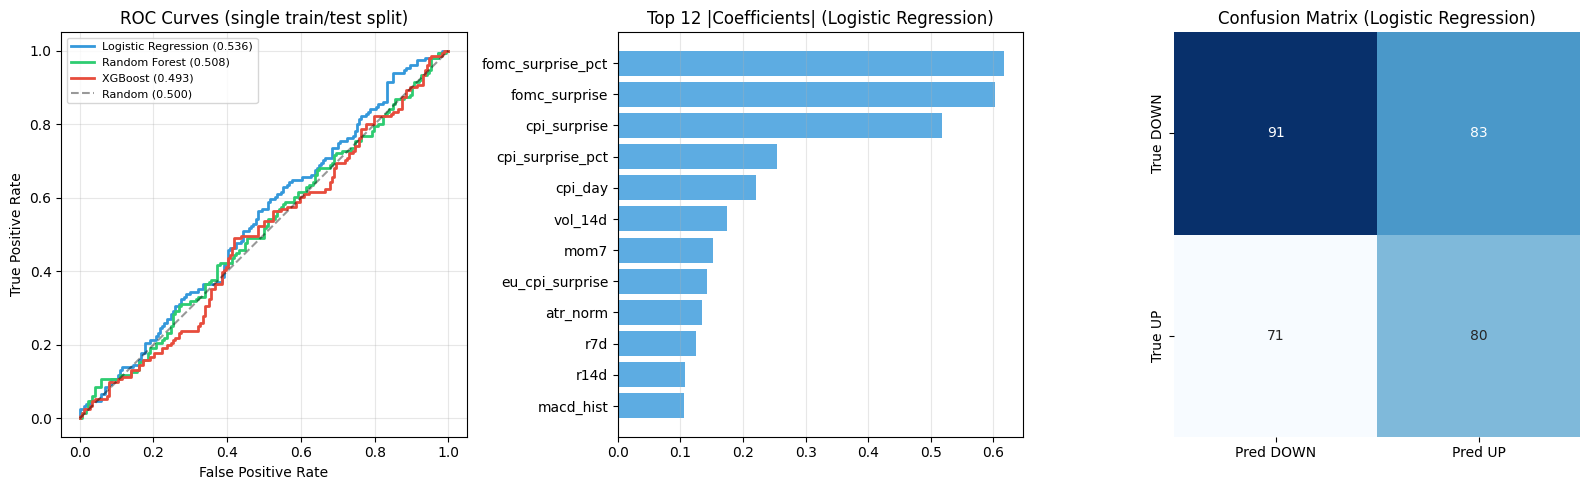

In [34]:
# diagnostic plots: ROC curves, feature importance, confusion matrix
from sklearn.metrics import roc_curve, confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colours = {'Logistic Regression': '#3498db',
           'Random Forest':       '#2ecc71',
           'XGBoost':             '#e74c3c'}

# ROC curves for all three models
ax = axes[0]
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    ax.plot(fpr, tpr, lw=2, color=colours[name],
            label=f"{name} ({res['auc']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (single train/test split)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Feature importance for best model (only if the model supports it)
ax = axes[1]
best_clf = results[best]['clf']
if hasattr(best_clf, 'feature_importances_'):
    imp = pd.Series(best_clf.feature_importances_,
                    index=feature_cols).sort_values(ascending=True).tail(12)
    ax.barh(imp.index, imp.values, color='#2ecc71', alpha=0.8)
    ax.set_title(f'Top 12 Feature Importances ({best})')
elif hasattr(best_clf, 'coef_'):
    coefs = pd.Series(best_clf.coef_[0], index=feature_cols)
    imp = coefs.abs().sort_values(ascending=True).tail(12)
    ax.barh(imp.index, imp.values, color='#3498db', alpha=0.8)
    ax.set_title(f'Top 12 |Coefficients| ({best})')
else:
    ax.text(0.5, 0.5, 'No feature importance available',
            ha='center', va='center')
    ax.set_title(f'Feature Importance ({best})')
ax.grid(True, alpha=0.3, axis='x')

# Confusion matrix for best model
ax = axes[2]
cm = confusion_matrix(y_test, results[best]['pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred DOWN', 'Pred UP'],
            yticklabels=['True DOWN', 'True UP'],
            cbar=False)
ax.set_title(f'Confusion Matrix ({best})')

plt.tight_layout()
plt.savefig('evaluation_diagnostics.png', dpi=200, bbox_inches='tight')
plt.show()

## 7. Trade Signal Generation

Converting model probabilities into signals with a confidence threshold.

- P(UP) > 0.57 → **BUY**
- P(UP) < 0.43 → **SELL**  
- Otherwise → **HOLD** (not confident enough)

Higher threshold = fewer signals but higher quality.
This implements the "configurable risk parameters" from Form B.


In [35]:
def get_signals(proba, buy_thresh=0.57, sell_thresh=0.43):
    signals = []
    for p in proba:
        if p >= buy_thresh:
            signals.append('BUY')
        elif p <= sell_thresh:
            signals.append('SELL')
        else:
            signals.append('HOLD')
    return np.array(signals)

# generate signals using best model
best_proba = results[best]['proba']
signals = get_signals(best_proba)

sig_counts = pd.Series(signals).value_counts()
print(f"Signal summary ({best}):")
print(f"  BUY:  {sig_counts.get('BUY',0)} ({sig_counts.get('BUY',0)/len(signals)*100:.1f}%)")
print(f"  SELL: {sig_counts.get('SELL',0)} ({sig_counts.get('SELL',0)/len(signals)*100:.1f}%)")
print(f"  HOLD: {sig_counts.get('HOLD',0)} ({sig_counts.get('HOLD',0)/len(signals)*100:.1f}%)")

# signal accuracy
y_arr = y_test.values
if (signals=='BUY').sum() > 0:
    buy_acc = (y_arr[signals=='BUY'] == 1).mean()
    print(f"\nBUY accuracy (price went UP): {buy_acc:.3f}")
if (signals=='SELL').sum() > 0:
    sell_acc = (y_arr[signals=='SELL'] == 0).mean()
    print(f"SELL accuracy (price fell):   {sell_acc:.3f}")


Signal summary (Logistic Regression):
  BUY:  39 (12.0%)
  SELL: 45 (13.8%)
  HOLD: 241 (74.2%)

BUY accuracy (price went UP): 0.513
SELL accuracy (price fell):   0.644


In [36]:
# run backtest across all three models for honest comparison
test_close = df['close'].iloc[split:].values
log_rets = np.diff(np.log(test_close))
test_dates = df.index[split+1:]
bah_return = np.cumsum(log_rets) * 100

backtest_results = {}

for name in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    proba = results[name]['proba']
    sigs = get_signals(proba)
    
    strat_rets = np.zeros(len(log_rets))
    for i in range(len(log_rets)):
        if i < len(sigs):
            if sigs[i] == 'BUY':
                strat_rets[i] = log_rets[i]
            elif sigs[i] == 'SELL':
                strat_rets[i] = -log_rets[i]
    
    cum_strat = np.cumsum(strat_rets) * 100
    sharpe = strat_rets.mean() / (strat_rets.std() + 1e-8) * np.sqrt(252)
    n_trades = (sigs != 'HOLD').sum()
    win_rate = (strat_rets[sigs[:-1] != 'HOLD'] > 0).mean() if n_trades > 0 else 0
    
    backtest_results[name] = {
        'signals': sigs,
        'strat_rets': strat_rets,
        'cum_strat': cum_strat,
        'final_return': cum_strat[-1],
        'sharpe': sharpe,
        'n_trades': n_trades,
        'win_rate': win_rate
    }

# print comparison table
print(f"{'Model':<25} {'Return':>10} {'Sharpe':>8} {'Trades':>8} {'Win Rate':>10}")
print("-" * 65)
print(f"{'Buy-and-hold':<25} {bah_return[-1]:>+9.2f}% {'—':>8} {'—':>8} {'—':>10}")
for name, r in backtest_results.items():
    marker = " (PRIMARY)" if name == PRIMARY_MODEL else ""
    print(f"{name+marker:<25} {r['final_return']:>+9.2f}% {r['sharpe']:>8.2f} {r['n_trades']:>8d} {r['win_rate']:>10.3f}")
    

Model                         Return   Sharpe   Trades   Win Rate
-----------------------------------------------------------------
Buy-and-hold                  +4.97%        —        —          —
Logistic Regression (PRIMARY)     +8.13%     1.51       84      0.578
Random Forest                 +1.66%     0.37       31      0.516
XGBoost                      +10.07%     1.45      121      0.463


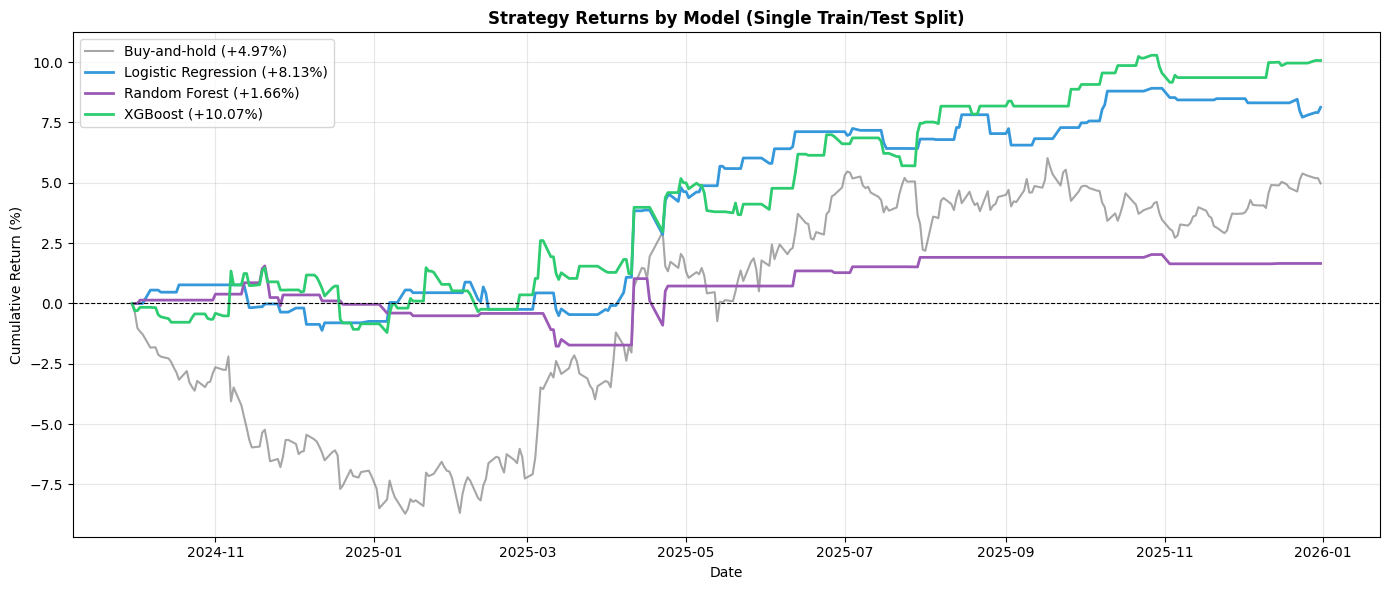

In [37]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = {'Logistic Regression': '#3498db', 'Random Forest': '#9b59b6', 'XGBoost': '#2ecc71'}

ax.plot(test_dates[:len(bah_return)], bah_return, color='gray', lw=1.5, alpha=0.7,
        label=f'Buy-and-hold ({bah_return[-1]:+.2f}%)')

for name, r in backtest_results.items():
    ax.plot(test_dates[:len(r['cum_strat'])], r['cum_strat'], 
            color=colors[name], lw=2,
            label=f"{name} ({r['final_return']:+.2f}%)")

ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_title('Strategy Returns by Model (Single Train/Test Split)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (%)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
# simple backtest
test_close = df['close'].iloc[split:].values
log_rets   = np.diff(np.log(test_close))
strat_rets = np.zeros(len(log_rets))

for i in range(len(log_rets)):
    if i < len(signals):
        if signals[i] == 'BUY':
            strat_rets[i] =  log_rets[i]
        elif signals[i] == 'SELL':
            strat_rets[i] = -log_rets[i]

cum_strat = np.cumsum(strat_rets) * 100
cum_bah   = np.cumsum(log_rets)   * 100
test_dates = df.index[split+1:]

print("Backtest Results:")
print(f"  Strategy return:    {cum_strat[-1]:+.2f}%")
print(f"  Buy-and-hold:       {cum_bah[-1]:+.2f}%")
sharpe = strat_rets.mean() / (strat_rets.std() + 1e-8) * np.sqrt(252)
print(f"  Sharpe ratio:       {sharpe:.2f}")
print(f"  Number of trades:   {(signals != 'HOLD').sum()}")
win_rate = (strat_rets[signals[:-1] != 'HOLD'] > 0).mean()
print(f"  Win rate:           {win_rate:.3f}")


Backtest Results:
  Strategy return:    +8.13%
  Buy-and-hold:       +4.97%
  Sharpe ratio:       1.51
  Number of trades:   84
  Win rate:           0.578


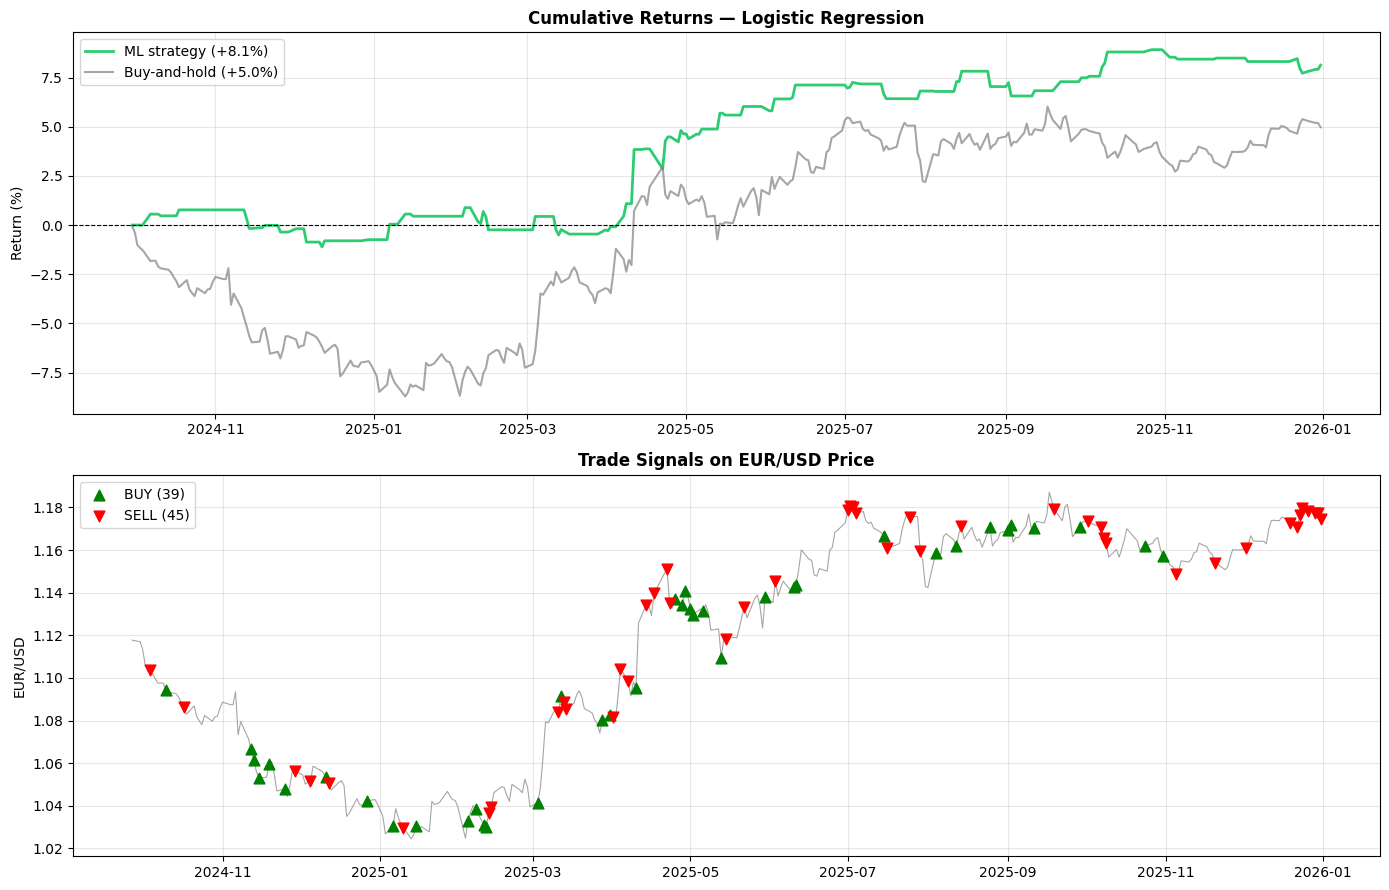

In [39]:
# plot backtest results
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# cumulative returns
ax = axes[0]
ax.plot(test_dates[:len(cum_strat)], cum_strat, color='#2ecc71', lw=2,
        label=f'ML strategy ({cum_strat[-1]:+.1f}%)')
ax.plot(test_dates[:len(cum_bah)],   cum_bah,   color='gray', lw=1.5, alpha=0.7,
        label=f'Buy-and-hold ({cum_bah[-1]:+.1f}%)')
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_title(f'Cumulative Returns — {best}', fontweight='bold')
ax.set_ylabel('Return (%)')
ax.legend(); ax.grid(True, alpha=0.3)

# signals on price chart
ax = axes[1]
test_dates_full = df.index[split:]
ax.plot(test_dates_full, test_close, color='gray', lw=0.8, alpha=0.7)

buy_mask  = signals == 'BUY'
sell_mask = signals == 'SELL'
if buy_mask.sum() > 0:
    ax.scatter(test_dates_full[buy_mask],  test_close[buy_mask],
               marker='^', color='green', s=60, zorder=5, label=f'BUY ({buy_mask.sum()})')
if sell_mask.sum() > 0:
    ax.scatter(test_dates_full[sell_mask], test_close[sell_mask],
               marker='v', color='red',   s=60, zorder=5, label=f'SELL ({sell_mask.sum()})')

ax.set_title('Trade Signals on EUR/USD Price', fontweight='bold')
ax.set_ylabel('EUR/USD')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Walk-Forward Evaluation

Single-split test results above reflect one historical period. Walk-forward validation simulates real-time deployment: train on past data, predict next 60 days, slide forward, retrain, repeat. Evaluates all three models across multiple historical regimes (Nov 2022 to Nov 2025) to test the robustness of single-split findings.

In [40]:
# walk-forward parameters
INITIAL_TRAIN_SIZE = 800
TEST_WINDOW = 60
STEP = 60

total_rows = len(df)
expected_folds = (total_rows - INITIAL_TRAIN_SIZE) // STEP

print(f"Dataset size:          {total_rows} rows")
print(f"Initial train size:    {INITIAL_TRAIN_SIZE} rows (~{INITIAL_TRAIN_SIZE/252:.1f} years)")
print(f"Test window per fold:  {TEST_WINDOW} rows (~{TEST_WINDOW/21:.1f} months)")
print(f"Step size:             {STEP} rows")
print(f"Expected fold count:   {expected_folds}")

Dataset size:          1623 rows
Initial train size:    800 rows (~3.2 years)
Test window per fold:  60 rows (~2.9 months)
Step size:             60 rows
Expected fold count:   13


In [41]:
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# tuned params from Section 6
lr_params  = lr_grid.best_params_
rf_params  = rf_grid.best_params_
xgb_params = xgb_grid.best_params_

# run walk-forward across all three models
wf_results = {'Logistic Regression': [], 'Random Forest': [], 'XGBoost': []}

train_end = INITIAL_TRAIN_SIZE
fold = 1

while train_end + TEST_WINDOW <= total_rows:
    # define train/test slices
    X_tr = df[feature_cols].iloc[:train_end]
    y_tr = df['target'].iloc[:train_end]
    X_te = df[feature_cols].iloc[train_end:train_end + TEST_WINDOW]
    y_te = df['target'].iloc[train_end:train_end + TEST_WINDOW]

    # LR needs scaling, fresh scaler per fold (no leakage)
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    fold_aucs = {}

    # Logistic Regression
    lr_m = LogisticRegression(**lr_params, max_iter=2000, random_state=42)
    lr_m.fit(X_tr_s, y_tr)
    lr_proba = lr_m.predict_proba(X_te_s)[:, 1]
    lr_auc = roc_auc_score(y_te, lr_proba)
    fold_aucs['Logistic Regression'] = lr_auc
    wf_results['Logistic Regression'].append({
        'fold': fold, 'train_end': df.index[train_end - 1].date(),
        'test_start': df.index[train_end].date(),
        'test_end': df.index[train_end + TEST_WINDOW - 1].date(),
        'n_train': train_end, 'auc': lr_auc, 'proba': lr_proba,
        'y_true': y_te.values, 'dates': df.index[train_end:train_end + TEST_WINDOW]
    })

    # Random Forest
    rf_m = RandomForestClassifier(**rf_params, random_state=42, n_jobs=-1)
    rf_m.fit(X_tr, y_tr)
    rf_proba = rf_m.predict_proba(X_te)[:, 1]
    rf_auc = roc_auc_score(y_te, rf_proba)
    fold_aucs['Random Forest'] = rf_auc
    wf_results['Random Forest'].append({
        'fold': fold, 'train_end': df.index[train_end - 1].date(),
        'test_start': df.index[train_end].date(),
        'test_end': df.index[train_end + TEST_WINDOW - 1].date(),
        'n_train': train_end, 'auc': rf_auc, 'proba': rf_proba,
        'y_true': y_te.values, 'dates': df.index[train_end:train_end + TEST_WINDOW]
    })

    # XGBoost
    xgb_m = XGBClassifier(**xgb_params, random_state=42, verbosity=0, n_jobs=-1)
    xgb_m.fit(X_tr, y_tr)
    xgb_proba = xgb_m.predict_proba(X_te)[:, 1]
    xgb_auc = roc_auc_score(y_te, xgb_proba)
    fold_aucs['XGBoost'] = xgb_auc
    wf_results['XGBoost'].append({
        'fold': fold, 'train_end': df.index[train_end - 1].date(),
        'test_start': df.index[train_end].date(),
        'test_end': df.index[train_end + TEST_WINDOW - 1].date(),
        'n_train': train_end, 'auc': xgb_auc, 'proba': xgb_proba,
        'y_true': y_te.values, 'dates': df.index[train_end:train_end + TEST_WINDOW]
    })

    print(f"Fold {fold}: test {df.index[train_end].date()} to {df.index[train_end + TEST_WINDOW - 1].date()} | "
          f"LR={lr_auc:.4f}  RF={rf_auc:.4f}  XGB={xgb_auc:.4f}")

    train_end += STEP
    fold += 1

print(f"\nCompleted {fold - 1} folds across 3 models")

Fold 1: test 2022-11-01 to 2023-01-23 | LR=0.4949  RF=0.4321  XGB=0.4254
Fold 2: test 2023-01-24 to 2023-04-17 | LR=0.5261  RF=0.5918  XGB=0.5195
Fold 3: test 2023-04-18 to 2023-07-10 | LR=0.4074  RF=0.4534  XGB=0.5196
Fold 4: test 2023-07-11 to 2023-10-02 | LR=0.5859  RF=0.4230  XGB=0.4576
Fold 5: test 2023-10-03 to 2023-12-25 | LR=0.5690  RF=0.5701  XGB=0.6663
Fold 6: test 2023-12-26 to 2024-03-18 | LR=0.5234  RF=0.5223  XGB=0.5201
Fold 7: test 2024-03-19 to 2024-06-10 | LR=0.5646  RF=0.6514  XGB=0.6286
Fold 8: test 2024-06-11 to 2024-09-02 | LR=0.5737  RF=0.5474  XGB=0.5463
Fold 9: test 2024-09-03 to 2024-11-25 | LR=0.4554  RF=0.4505  XGB=0.4176
Fold 10: test 2024-11-26 to 2025-02-18 | LR=0.5301  RF=0.3225  XGB=0.4475
Fold 11: test 2025-02-19 to 2025-05-15 | LR=0.5410  RF=0.4759  XGB=0.4444
Fold 12: test 2025-05-16 to 2025-08-07 | LR=0.5670  RF=0.5871  XGB=0.4900
Fold 13: test 2025-08-08 to 2025-10-30 | LR=0.6596  RF=0.5840  XGB=0.5606

Completed 13 folds across 3 models


In [42]:
import pandas as pd

summary = {}
for name in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    aucs = [r['auc'] for r in wf_results[name]]
    summary[name] = {
        'mean': sum(aucs) / len(aucs),
        'std': pd.Series(aucs).std(),
        'min': min(aucs),
        'max': max(aucs),
        'above_50': sum(1 for a in aucs if a > 0.50),
        'above_55': sum(1 for a in aucs if a > 0.55),
        'n_folds': len(aucs)
    }

print(f"{'Model':<25} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8} {'>0.50':>8} {'>0.55':>8}")
print("-" * 75)
for name, s in summary.items():
    marker = " *" if name == PRIMARY_MODEL else "  "
    print(f"{name:<23}{marker} {s['mean']:>8.4f} {s['std']:>8.4f} {s['min']:>8.4f} {s['max']:>8.4f} "
          f"{s['above_50']:>3d}/{s['n_folds']:<3d}  {s['above_55']:>3d}/{s['n_folds']:<3d}")

print("\n* = Primary model")

Model                         Mean      Std      Min      Max    >0.50    >0.55
---------------------------------------------------------------------------
Logistic Regression     *   0.5383   0.0626   0.4074   0.6596  10/13     6/13 
Random Forest               0.5086   0.0913   0.3225   0.6514   7/13     5/13 
XGBoost                     0.5110   0.0762   0.4176   0.6663   7/13     3/13 

* = Primary model


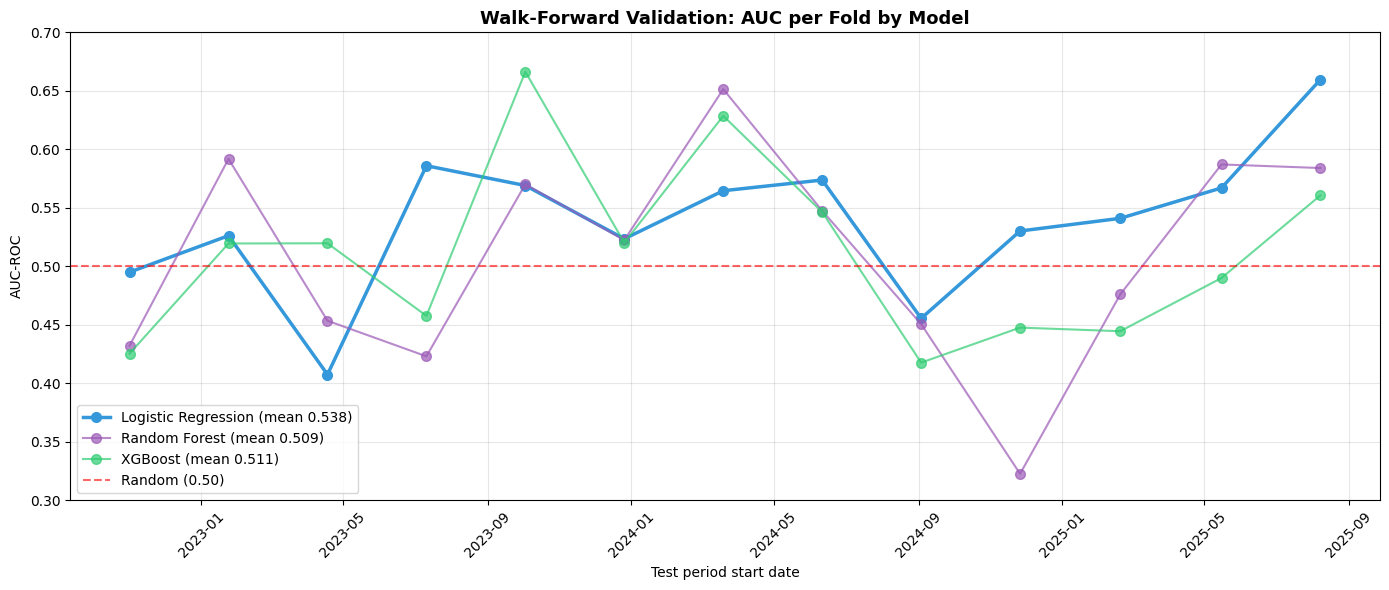

In [43]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))

colors = {'Logistic Regression': '#3498db', 'Random Forest': '#9b59b6', 'XGBoost': '#2ecc71'}

for name in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    dates = [r['test_start'] for r in wf_results[name]]
    aucs = [r['auc'] for r in wf_results[name]]
    lw = 2.5 if name == PRIMARY_MODEL else 1.5
    alpha = 1.0 if name == PRIMARY_MODEL else 0.7
    ax.plot(dates, aucs, marker='o', color=colors[name], lw=lw, alpha=alpha,
            markersize=7, label=f"{name} (mean {summary[name]['mean']:.3f})")

ax.axhline(0.5, color='red', linestyle='--', alpha=0.6, label='Random (0.50)')

ax.set_title('Walk-Forward Validation: AUC per Fold by Model', fontweight='bold', fontsize=13)
ax.set_xlabel('Test period start date')
ax.set_ylabel('AUC-ROC')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.30, 0.70)
plt.xticks(rotation=45)
plt.savefig('walkforward_auc_three_models.png', dpi=200, bbox_inches='tight')
plt.tight_layout()
plt.show()

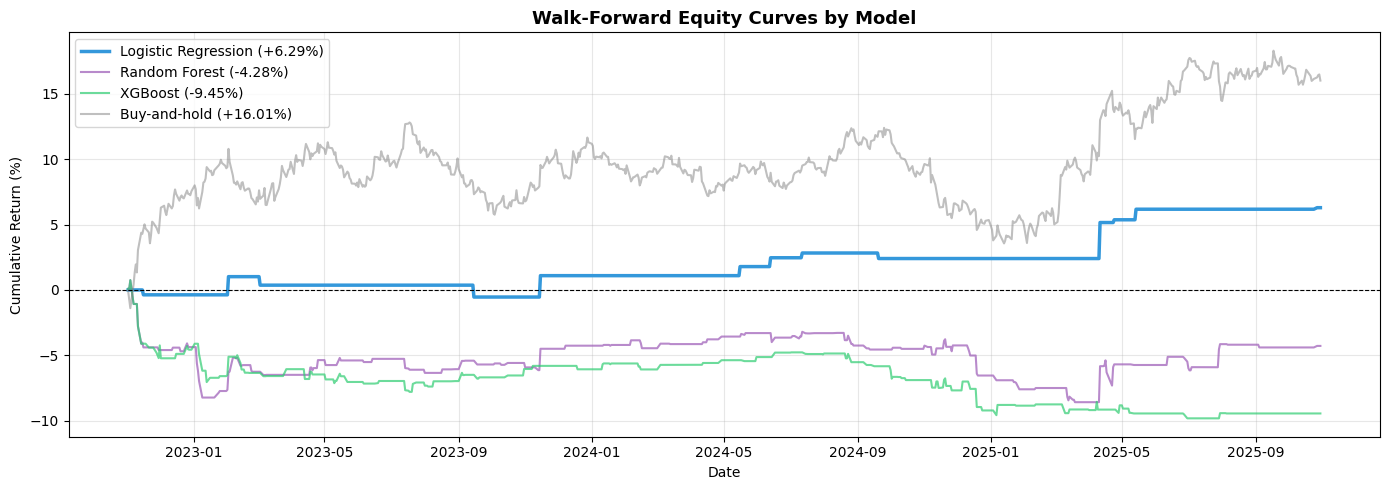

In [44]:
import numpy as np

fig, ax = plt.subplots(figsize=(14, 5))

for name in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    all_proba = np.concatenate([r['proba'] for r in wf_results[name]])
    all_dates = pd.DatetimeIndex(np.concatenate([r['dates'] for r in wf_results[name]]))
    all_signals = get_signals(all_proba)

    test_close = df.loc[all_dates, 'close'].values
    log_rets = np.diff(np.log(test_close))
    strat_rets = np.zeros(len(log_rets))
    for i in range(len(log_rets)):
        if i < len(all_signals):
            if all_signals[i] == 'BUY':
                strat_rets[i] = log_rets[i]
            elif all_signals[i] == 'SELL':
                strat_rets[i] = -log_rets[i]
    cum_strat = np.cumsum(strat_rets) * 100

    lw = 2.5 if name == PRIMARY_MODEL else 1.5
    alpha = 1.0 if name == PRIMARY_MODEL else 0.7
    ax.plot(all_dates[1:], cum_strat, color=colors[name], lw=lw, alpha=alpha,
            label=f"{name} ({cum_strat[-1]:+.2f}%)")

# buy-and-hold reference using LR's date range
all_dates_ref = pd.DatetimeIndex(np.concatenate([r['dates'] for r in wf_results[PRIMARY_MODEL]]))
test_close_ref = df.loc[all_dates_ref, 'close'].values
log_rets_ref = np.diff(np.log(test_close_ref))
cum_bah = np.cumsum(log_rets_ref) * 100
ax.plot(all_dates_ref[1:], cum_bah, color='gray', lw=1.5, alpha=0.5,
        label=f'Buy-and-hold ({cum_bah[-1]:+.2f}%)')

ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_title('Walk-Forward Equity Curves by Model', fontweight='bold', fontsize=13)
ax.set_xlabel('Date'); ax.set_ylabel('Cumulative Return (%)')
ax.legend(loc='best'); ax.grid(True, alpha=0.3)
plt.savefig('walkforward_equity_three_models.png', dpi=200, bbox_inches='tight')
plt.tight_layout()
plt.show()

## 9. Feature importance and Interpretability

Two complementary perspectives:

- **Permutation importance** (Logistic Regression, primary model): measures
  how much performance drops when each feature's values are randomly shuffled.
  Model-agnostic, robust, identifies the features most critical to the
  strategy's predictions.

- **SHAP values** (Logistic Regression, primary model): assigns each prediction a
  decomposition into per-feature contributions. The summary plot shows both
  feature importance and direction of effect.

In [45]:
# install shap if not already (one-time)
import importlib
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Top 15 features by permutation importance (LR):
                 feature  importance_mean  importance_std
eu_core_cpi_surprise_pct           0.0134          0.0090
                 nfp_day           0.0113          0.0077
        days_since_event           0.0067          0.0062
        days_until_event           0.0040          0.0112
            ecb_rate_day           0.0035          0.0026
    eu_core_cpi_surprise           0.0033          0.0051
                    mom7           0.0031          0.0122
        nfp_surprise_pct           0.0029          0.0066
                    r14d           0.0016          0.0043
               event_day           0.0008          0.0008
                  vol_5d           0.0006          0.0027
                     r1d           0.0005          0.0053
              ma50_slope           0.0003          0.0021
                atr_norm           0.0003          0.0021
                     r5d           0.0002          0.0008


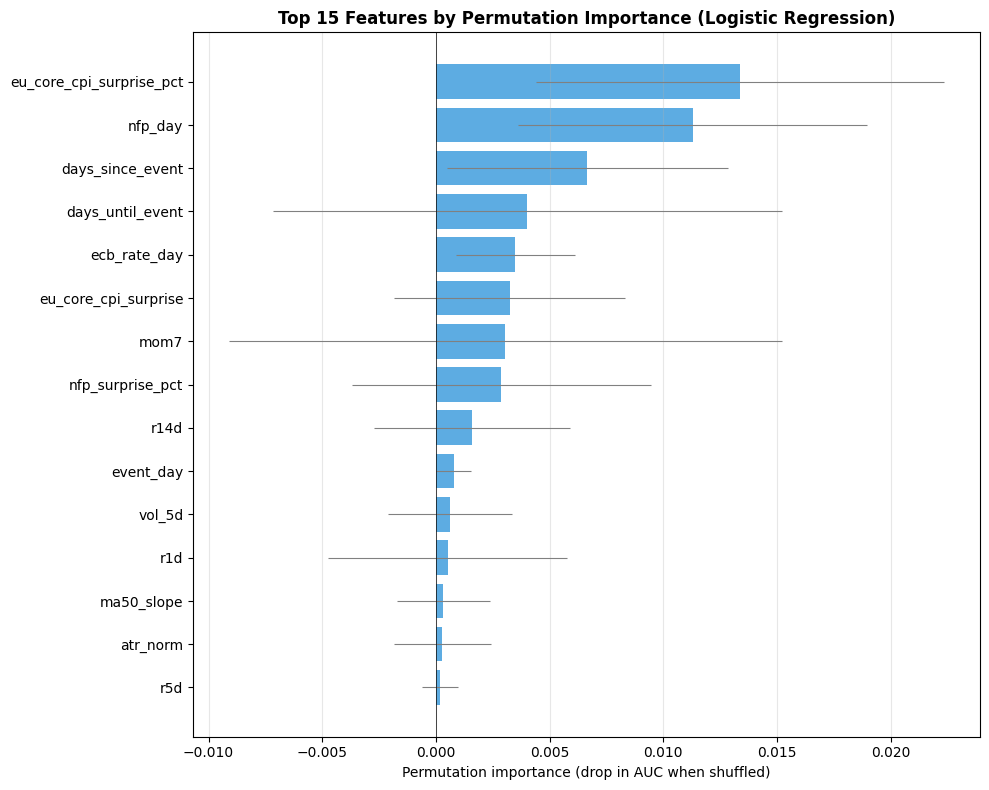

In [46]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# use the tuned LR model (lr_m) fit on scaled training data
perm = permutation_importance(
    lr_m,
    X_test_s,   # use scaled test features for LR
    y_test,
    n_repeats=20,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1
)

# build dataframe of results
perm_df = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

print("Top 15 features by permutation importance (LR):")
print(perm_df.head(15).round(4).to_string(index=False))

# plot top 15
fig, ax = plt.subplots(figsize=(10, 8))
top = perm_df.head(15).iloc[::-1]
ax.barh(top['feature'], top['importance_mean'],
        xerr=top['importance_std'], color='#3498db', alpha=0.8,
        error_kw={'ecolor': 'gray', 'lw': 0.8})
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('Permutation importance (drop in AUC when shuffled)')
ax.set_title('Top 15 Features by Permutation Importance (Logistic Regression)',
             fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('permutation_importance_lr.png', dpi=200, bbox_inches='tight')
plt.show()

In [47]:
import shap
import matplotlib.pyplot as plt

# LinearExplainer for Logistic Regression — no compatibility issues
explainer = shap.LinearExplainer(lr_m, X_train_s)
shap_values = explainer.shap_values(X_test_s)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Test set shape: {X_test_s.shape}")

SHAP values shape: (325, 42)
Test set shape: (325, 42)


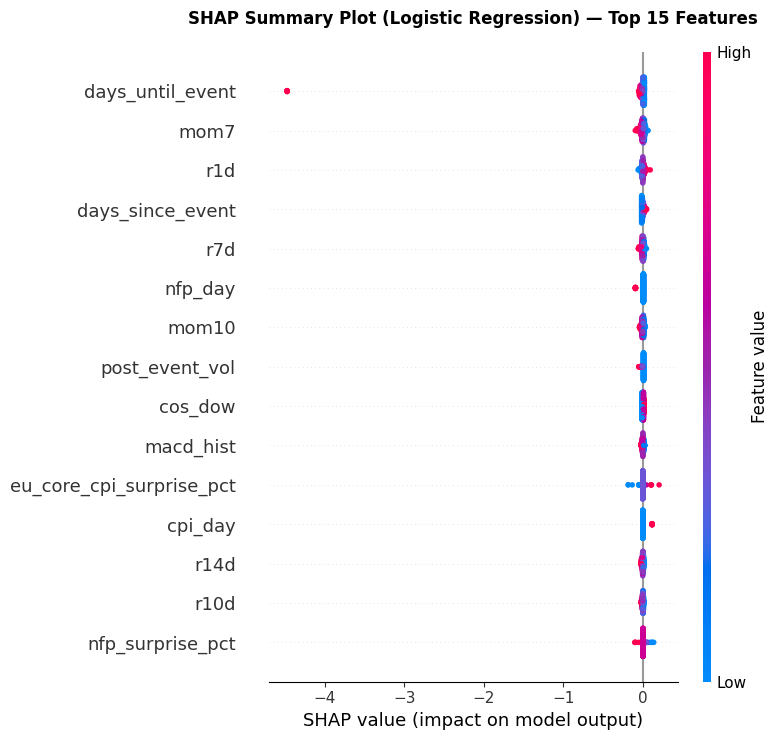

In [48]:
import matplotlib.pyplot as plt
import shap

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_s, feature_names=feature_cols,
                  show=False, max_display=15)
plt.title('SHAP Summary Plot (Logistic Regression) — Top 15 Features', 
          fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_summary_lr.png', dpi=200, bbox_inches='tight')
plt.show()

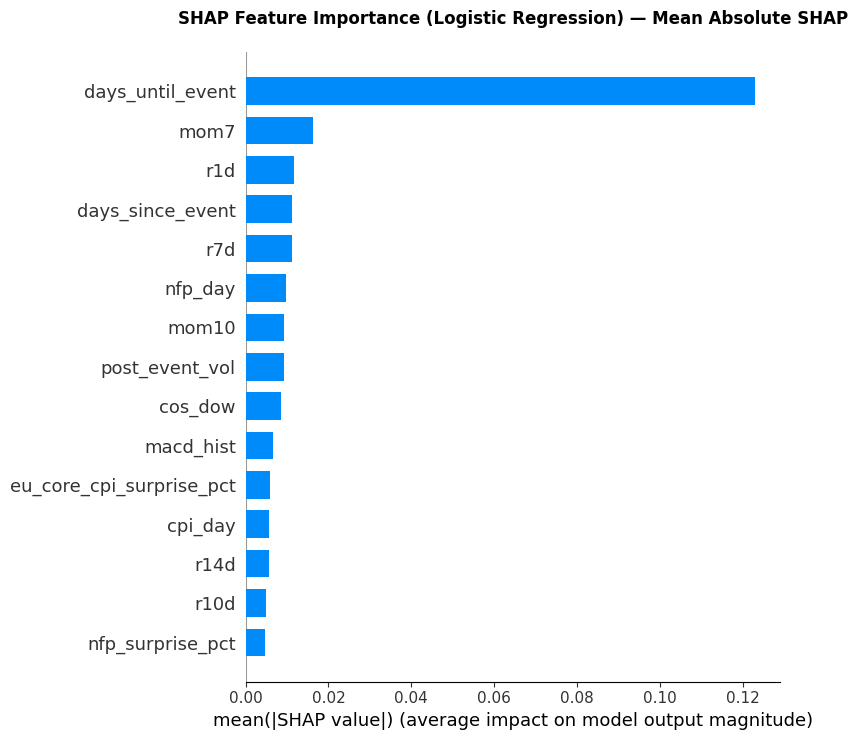

In [49]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_s, feature_names=feature_cols,
                  plot_type='bar', show=False, max_display=15)
plt.title('SHAP Feature Importance (Logistic Regression) — Mean Absolute SHAP', 
          fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_bar_lr.png', dpi=200, bbox_inches='tight')
plt.show()

In [50]:
## 9b. Ablation Study

feature_groups = {
    'USD Events':    [c for c in feature_cols if any(x in c for x in ['cpi', 'nfp', 'fomc'])],
    'ECB Events':    [c for c in feature_cols if any(x in c for x in ['ecb', 'eu_cpi', 'eu_core'])],
    'Regime':        ['above_200ma', 'dist_200ma', 'ma50_slope'],
    'Technical':     ['rsi', 'macd_hist', 'bb_pct', 'atr_norm'],
    'Momentum':      [c for c in feature_cols if c.startswith(('r1d','r5d','r7d','r10d','r14d','mom'))],
    'Volatility':    ['vol_5d', 'vol_14d', 'price_pct_14d', 'post_event_vol'],
    'Time':          ['cos_dow', 'sin_dow', 'days_since_event', 'days_until_event'],
}

baseline_auc = roc_auc_score(y_test, lr_m.predict_proba(X_test_s)[:,1])
print(f"Baseline AUC (all features): {baseline_auc:.4f}\n")

ablation_results = []
for group, cols in feature_groups.items():
    # drop the group, refit, evaluate
    remaining = [c for c in feature_cols if c not in cols]
    scaler_abl = StandardScaler()
    X_tr_abl = scaler_abl.fit_transform(X_train[remaining])
    X_te_abl = scaler_abl.transform(X_test[remaining])
    
    lr_abl = LogisticRegression(**lr_grid.best_params_, max_iter=2000, random_state=42)
    lr_abl.fit(X_tr_abl, y_train)
    auc_abl = roc_auc_score(y_test, lr_abl.predict_proba(X_te_abl)[:,1])
    drop = baseline_auc - auc_abl
    ablation_results.append({'group': group, 'auc': auc_abl, 'drop': drop, 'n_features_removed': len(cols)})
    print(f"{group:<20} AUC: {auc_abl:.4f}  drop: {drop:+.4f}  (removed {len(cols)} features)")

Baseline AUC (all features): 0.5820

USD Events           AUC: 0.5346  drop: +0.0474  (removed 15 features)
ECB Events           AUC: 0.5430  drop: +0.0390  (removed 9 features)
Regime               AUC: 0.5617  drop: +0.0203  (removed 3 features)
Technical            AUC: 0.5617  drop: +0.0204  (removed 4 features)
Momentum             AUC: 0.5507  drop: +0.0314  (removed 8 features)
Volatility           AUC: 0.5655  drop: +0.0165  (removed 4 features)
Time                 AUC: 0.5578  drop: +0.0242  (removed 4 features)


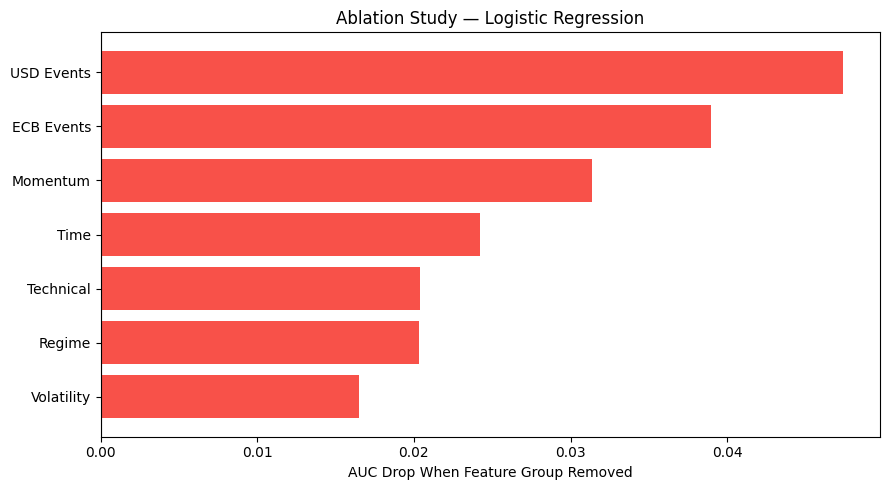

In [54]:
# Save ablation study plot
ablation_df = pd.DataFrame(ablation_results).sort_values('drop', ascending=True)

plt.figure(figsize=(9, 5))
colors = ['#2ea043' if d < 0 else '#f85149' for d in ablation_df['drop']]
plt.barh(ablation_df['group'], ablation_df['drop'], color=colors)
plt.axvline(0, color='#8b949e', linewidth=0.8)
plt.xlabel('AUC Drop When Feature Group Removed')
plt.title('Ablation Study — Logistic Regression')
plt.tight_layout()
plt.savefig('ablation_study_lr.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import pickle

# save trained model + scaler + feature list
with open('fyp_model.pkl', 'wb') as f:
    pickle.dump({
        'model': lr_m,
        'scaler': scaler,  
        'feature_cols': feature_cols
    }, f)

print("Model saved to fyp_model.pkl")

Model saved to fyp_model.pkl


In [52]:
with open('fyp_model.pkl', 'rb') as f:
    saved = pickle.load(f)

print("Keys:", saved.keys())
print("Model:", saved['model'])
print("Scaler:", saved['scaler'])
print("Features:", len(saved['feature_cols']), "features")
print(saved['feature_cols'][:5])

print(saved['feature_cols'])

Keys: dict_keys(['model', 'scaler', 'feature_cols'])
Model: LogisticRegression(C=0.001, max_iter=2000, random_state=42, solver='saga')
Scaler: StandardScaler()
Features: 42 features
['cpi_surprise', 'cpi_day', 'nfp_surprise', 'nfp_day', 'fomc_surprise']
['cpi_surprise', 'cpi_day', 'nfp_surprise', 'nfp_day', 'fomc_surprise', 'fomc_day', 'ecb_rate_surprise', 'ecb_rate_day', 'eu_cpi_surprise', 'eu_cpi_day', 'eu_core_cpi_surprise', 'eu_core_cpi_day', 'cpi_surprise_pct', 'nfp_surprise_pct', 'fomc_surprise_pct', 'ecb_rate_surprise_pct', 'eu_cpi_surprise_pct', 'eu_core_cpi_surprise_pct', 'event_day', 'days_since_event', 'days_until_event', 'r1d', 'r5d', 'r7d', 'r10d', 'r14d', 'mom5', 'mom7', 'mom10', 'vol_5d', 'vol_14d', 'price_pct_14d', 'above_200ma', 'dist_200ma', 'ma50_slope', 'cos_dow', 'sin_dow', 'rsi', 'macd_hist', 'bb_pct', 'atr_norm', 'post_event_vol']


In [53]:
print("=== QUICK SANITY CHECK ===")
print(f"Dataset rows: {len(df)}")
print(f"Features: {len(feature_cols)}")
lr_auc = results['Logistic Regression']['auc']
print(f"LR test AUC: {lr_auc:.4f}")
print(f"LR best params: {lr_grid.best_params_}")
# check walk-forward results directly
lr_wf_aucs = [r['auc'] for r in wf_results['Logistic Regression']]
print(f"WF LR mean AUC: {np.mean(lr_wf_aucs):.4f}")
print(f"WF LR folds>0.5: {sum(a>0.5 for a in lr_wf_aucs)}/13")
print(f"Baseline ablation AUC: {baseline_auc:.4f}")
print(f"Model in pkl: {saved['model']}")

=== QUICK SANITY CHECK ===
Dataset rows: 1623
Features: 42
LR test AUC: 0.5358
LR best params: {'C': 0.001, 'penalty': 'l2', 'solver': 'saga'}
WF LR mean AUC: 0.5383
WF LR folds>0.5: 10/13
Baseline ablation AUC: 0.5820
Model in pkl: LogisticRegression(C=0.001, max_iter=2000, random_state=42, solver='saga')


## 10. Summary and Next Steps

### Results

Logistic Regression (C=0.001, L2, saga) was selected as the primary model 
following single-split evaluation and walk-forward validation across 13 
expanding windows (Nov 2022 – Oct 2025).

Single-split test AUC: 0.5358. Backtest return: +8.13%, Sharpe 1.51, 
win rate 0.578 across 84 trades.

Walk-forward mean AUC: 0.5383 (std 0.0626), with 10/13 folds above random 
and 6/13 above 0.55. Two catastrophic folds coincide with sustained USD 
strength regimes, confirming regime dependency as the binding constraint.

Walk-forward equity curve: LR +6.29% vs buy-and-hold +16.01%, indicating 
the model captures directional signal but underperforms in strongly trending 
bullish regimes.

Key finding: the project characterises the predictability boundary of EUR/USD 
around high-impact macro events (NFP, CPI, FOMC, ECB). The noise ceiling — 
not model complexity or hyperparameters — is the primary limiting factor. 
AUC consistently converges to 0.51–0.54 regardless of model class.

